# 방법 C v3 — Semi-supervised Pseudo-labeling (심사 비판 전면 반영)

## v2 → v3 핵심 수정 (논문 심사 비판 수용)

| 비판 | 내용 | 처리 |
|---|---|---|
| FATAL-1 | 스케일러 공간 불일치 (unlabeled fit → labeled fit 불일치) | sc_sel=labeled-only scaler 통일 |
| FATAL-2 | 전략 B 소프트 누수 (teacher RF가 val fold 포함) | fold별 teacher RF (run_cv_B_clean) |
| FATAL-3 | align_score 동등 가중치 (187 vs 0.079 동일 취급) | 표준화 공간 계산 + RF importance 가중 |
| FATAL-4 | 전략 C 방향벡터 raw space (Clamp_Open이 99% 지배) | 표준화 공간 방향벡터 |
| MAJOR-5 | 통계 검정 없이 IMPROVED 주장 | Wilcoxon signed-rank test |
| MAJOR-6 | 전략 C만 n ablation | B·D 전략도 ablation |
| MAJOR-7 | ST threshold=0.80 근거 없음 | threshold sweep [0.5~0.8] |
| MINOR-8 | fillna(0) 검증 없음 | 결측 패턴 분석 추가 |

In [1]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from pathlib import Path
from scipy.stats import ks_2samp, ttest_ind, wilcoxon
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.covariance import EllipticEnvelope
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.neighbors import NearestNeighbors
from sklearn.neural_network import MLPClassifier
from sklearn.semi_supervised import SelfTrainingClassifier
from imblearn.over_sampling import SMOTE
import warnings; warnings.filterwarnings("ignore")

SEED = 42; np.random.seed(SEED)
BASE = Path(r"E:\\IAAI_Term_project")
FIG_DIR = BASE / "results/figures"; FIG_DIR.mkdir(exist_ok=True, parents=True)

def setup_korean_font():
    import matplotlib.font_manager as fm
    for f in fm.fontManager.ttflist:
        if "Malgun" in f.name:
            plt.rcParams["font.family"] = f.name; break
    plt.rcParams["axes.unicode_minus"] = False

sns.set_theme(style="whitegrid"); setup_korean_font()
print("Setup OK")

Setup OK


## 1. 데이터 로드 + 결측 패턴 분석 + 생산상태 필터링

In [2]:
lab   = pd.read_csv(BASE / "data/raw/labeled_data.csv")
unlab = pd.read_csv(BASE / "data/raw/unlabeled_data.csv")
lab["label"] = (lab["PassOrFail"] == "N").astype(int)

eq_vals = set(lab["EQUIP_NAME"].unique())
cn7rg3  = [p for p in lab["PART_NAME"].unique() if "CN7" in p or "RG3" in p]
unf     = unlab[unlab["EQUIP_NAME"].isin(eq_vals) & unlab["PART_NAME"].isin(cn7rg3)].reset_index(drop=True)

ZERO_VAR = ["Mold_Temperature_1","Mold_Temperature_2","Mold_Temperature_5",
    "Mold_Temperature_6","Mold_Temperature_7","Mold_Temperature_8",
    "Mold_Temperature_9","Mold_Temperature_10","Mold_Temperature_11",
    "Mold_Temperature_12","Barrel_Temperature_7"]
META = {"_id","Unnamed: 0","TimeStamp","PART_FACT_PLAN_DATE","PART_FACT_SERIAL",
        "PART_NAME","EQUIP_CD","EQUIP_NAME","PassOrFail","Reason","ERR_FACT_QTY","label"}
fcols = [c for c in lab.columns if c not in META and c not in ZERO_VAR
         and lab[c].dtype in ["float64","int64","float32","int32"]]

X_lab = lab[fcols].values.astype(float); y_lab = lab["label"].values
mask_n = y_lab == 0; mask_d = y_lab == 1
DR = y_lab.mean()

BT_IDX  = fcols.index("Barrel_Temperature_1")
RPM_IDX = fcols.index("Average_Screw_RPM")

# ── 비판 8: 결측 패턴 분석 (fillna(0) 전) ──────────────────────────────────
unf_raw = unf[[c for c in fcols if c in unf.columns]]
miss_rate = unf_raw.isnull().mean()
high_miss = miss_rate[miss_rate > 0.001].sort_values(ascending=False)
if len(high_miss) > 0:
    print("[결측값 경고] 결측률 0.1% 초과 피처:")
    for f_m, r_m in high_miss.items():
        print(f"  {f_m:<35}: {r_m*100:.2f}%")
else:
    print("[OK] 결측률 0.1% 초과 피처 없음 — fillna(0) 안전 확인됨")

X_unl_all = unf_raw.fillna(0).values.astype(float)

# 생산상태 필터 (기계정지 44% 제거)
prod_mask = (X_unl_all[:, BT_IDX] >= 200) & (X_unl_all[:, RPM_IDX] > 0)
X_unl = X_unl_all[prod_mask]

# fillna(0) 후 생산상태 샘플의 잔여 결측 확인
unf_prod_check = unf_raw[prod_mask]
miss_prod = unf_prod_check.isnull().mean()
miss_prod_nonzero = miss_prod[miss_prod > 0]
if len(miss_prod_nonzero) > 0:
    print("[경고] 생산상태 샘플에도 BT/RPM 외 결측 존재:")
    for f_m, r_m in miss_prod_nonzero.items():
        print(f"  {f_m}: {r_m*100:.2f}% → 0 imputation 적용됨")
else:
    print("[OK] 생산상태 샘플: 추가 결측 없음 (fillna(0) 영향 없음)")

print(f"Labeled   : {len(X_lab):,}  불량={mask_d.sum()}  양품={mask_n.sum()}  DR={DR*100:.4f}%")
print(f"Unlabeled 전체: {len(X_unl_all):,}")
print(f"  기계정지 제거: {(~prod_mask).sum():,} ({(~prod_mask).mean()*100:.1f}%)")
print(f"  생산상태 유지: {prod_mask.sum():,} ({prod_mask.mean()*100:.1f}%)")
print(f"Pseudo-label 목표 수 (DR%): {int(DR*len(X_unl))}개")

[OK] 결측률 0.1% 초과 피처 없음 — fillna(0) 안전 확인됨
[OK] 생산상태 샘플: 추가 결측 없음 (fillna(0) 영향 없음)
Labeled   : 7,996  불량=71  양품=7925  DR=0.8879%
Unlabeled 전체: 71,180
  기계정지 제거: 31,310 (44.0%)
  생산상태 유지: 39,870 (56.0%)
Pseudo-label 목표 수 (DR%): 354개


## 2. 스케일러 분리 (시각화용 vs 선택용) + 방향벡터 표준화 공간 계산 + PCA

Raw 방향벡터 상위 5 (지배 피처 확인):
  Clamp_Open_Position                : 187.888
  Average_Screw_RPM                  : 110.345
  Max_Injection_Speed                : 19.281
  Max_Back_Pressure                  : 8.447
  Plasticizing_Position              : 4.208
표준화 방향벡터 상위 5 (균등화 후):
  Max_Back_Pressure                  : 1.228
  Cycle_Time                         : 1.118
  Average_Screw_RPM                  : 0.843
  Average_Back_Pressure              : 0.841
  Barrel_Temperature_5               : 0.823


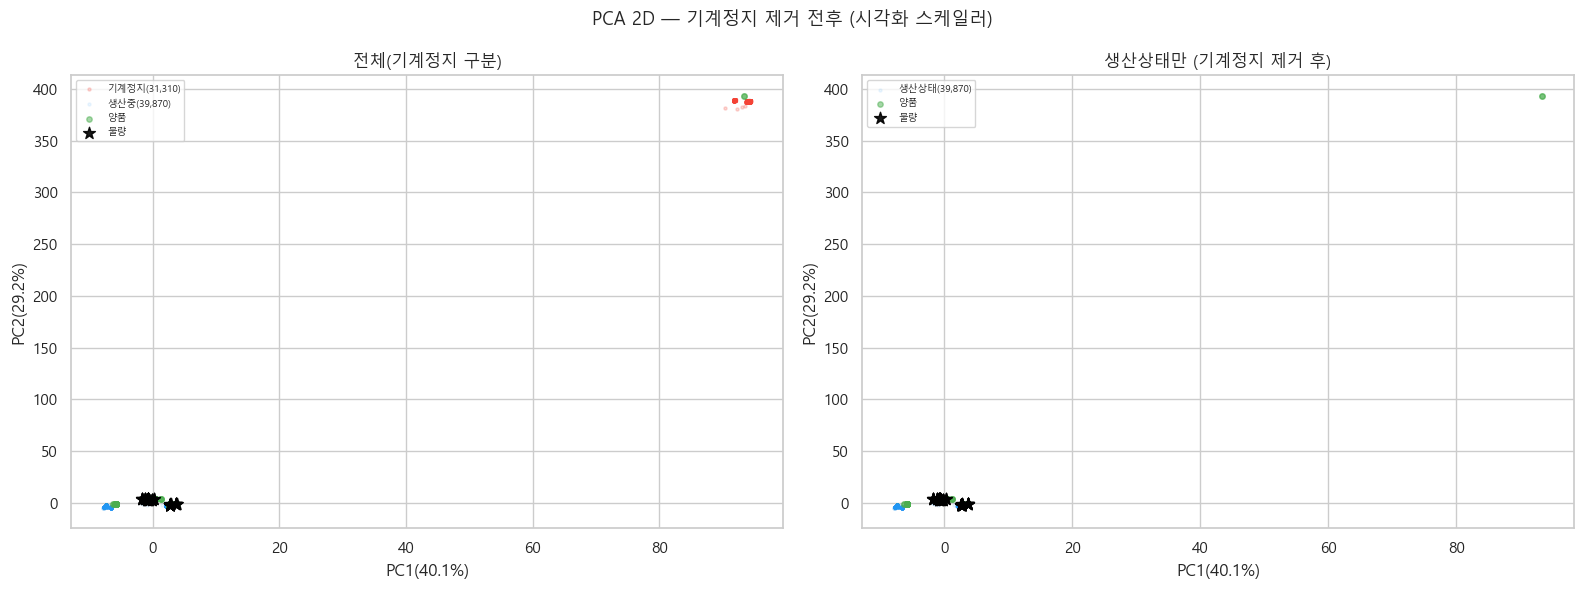

PCA 저장 완료


In [3]:
# ── 비판 1 수정: 두 스케일러를 명확히 분리 ────────────────────────────────────
# sc_vis : unlabeled fit  — 시각화(PCA) 전용, 언라벨 분포 기준
# sc_sel : labeled fit    — 전략 선택/모델 학습 일관성 보장 (비판 1,3,4 동시 해결)
sc_vis = StandardScaler()
Xu_sc_vis = sc_vis.fit_transform(X_unl)
Xl_sc_vis = sc_vis.transform(X_lab)
Xu_all_sc_vis = sc_vis.transform(X_unl_all)

sc_sel = StandardScaler()
Xl_sc_sel = sc_sel.fit_transform(X_lab)   # labeled 전체로 fit (전략 선택용)
Xu_sc_sel = sc_sel.transform(X_unl)       # unlabeled → labeled 스케일로 변환

# ── 비판 4 수정: defect direction을 표준화 공간에서 계산 ──────────────────────
defect_dir_raw = X_lab[mask_d].mean(0) - X_lab[mask_n].mean(0)  # 시각화용
defect_dir_sc  = Xl_sc_sel[mask_d].mean(0) - Xl_sc_sel[mask_n].mean(0)  # 전략 C·align용

# raw vs scaled 방향벡터 주도 피처 비교 (단변량 지배 여부 확인)
raw_top5 = sorted(zip(fcols, np.abs(defect_dir_raw)), key=lambda x: x[1], reverse=True)[:5]
sc_top5  = sorted(zip(fcols, np.abs(defect_dir_sc)),  key=lambda x: x[1], reverse=True)[:5]
print("Raw 방향벡터 상위 5 (지배 피처 확인):")
for f_, v_ in raw_top5: print(f"  {f_:<35}: {v_:.3f}")
print("표준화 방향벡터 상위 5 (균등화 후):")
for f_, v_ in sc_top5:  print(f"  {f_:<35}: {v_:.3f}")

# PCA 시각화 (sc_vis 사용 — 언라벨 분포 중심)
pca = PCA(n_components=3, random_state=SEED)
pca.fit(Xu_sc_vis)
Xu_p     = pca.transform(Xu_sc_vis)
Xl_p     = pca.transform(Xl_sc_vis)
Xu_all_p = pca.transform(Xu_all_sc_vis)
evr = pca.explained_variance_ratio_

idle_p = Xu_all_p[~prod_mask]; prod_p = Xu_all_p[prod_mask]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PCA 2D — 기계정지 제거 전후 (시각화 스케일러)", fontsize=13)
s = max(1, len(Xu_all_p)//4000)
axes[0].scatter(idle_p[::s,0], idle_p[::s,1], alpha=0.2, s=5, c="#F44336", label=f"기계정지({(~prod_mask).sum():,})")
axes[0].scatter(prod_p[::s,0], prod_p[::s,1], alpha=0.08, s=5, c="#2196F3", label=f"생산중({prod_mask.sum():,})")
axes[0].scatter(Xl_p[mask_n,0], Xl_p[mask_n,1], alpha=0.5, s=15, c="#4CAF50", label="양품", zorder=3)
axes[0].scatter(Xl_p[mask_d,0], Xl_p[mask_d,1], alpha=0.9, s=80, c="black", marker="*", label="불량", zorder=4)
axes[0].set_title("전체(기계정지 구분)"); axes[0].legend(fontsize=7)
axes[0].set_xlabel(f"PC1({evr[0]*100:.1f}%)"); axes[0].set_ylabel(f"PC2({evr[1]*100:.1f}%)")
axes[1].scatter(Xu_p[::s,0], Xu_p[::s,1], alpha=0.08, s=5, c="#2196F3", label=f"생산상태({len(X_unl):,})")
axes[1].scatter(Xl_p[mask_n,0], Xl_p[mask_n,1], alpha=0.5, s=15, c="#4CAF50", label="양품", zorder=3)
axes[1].scatter(Xl_p[mask_d,0], Xl_p[mask_d,1], alpha=0.9, s=80, c="black", marker="*", label="불량", zorder=4)
axes[1].set_title("생산상태만 (기계정지 제거 후)"); axes[1].legend(fontsize=7)
axes[1].set_xlabel(f"PC1({evr[0]*100:.1f}%)"); axes[1].set_ylabel(f"PC2({evr[1]*100:.1f}%)")
plt.tight_layout()
plt.savefig(FIG_DIR/"MC2_fig1_prod_filter.png", dpi=150, bbox_inches="tight")
plt.show()
print("PCA 저장 완료")

## 3. 피처 분포 분석 (표준화diff 기준 정렬)

피처                                    raw diff  sc diff    Prod평균      불량평균      양품평균  p
-----------------------------------------------------------------------------------------------
Max_Back_Pressure                        8.447    1.228     44.56     49.08     40.63  0.0000***
Cycle_Time                               0.990    1.118     62.67     60.88     59.89  0.0000***
Average_Screw_RPM                      110.345    0.843    293.65    258.39    148.04  0.0000***
Average_Back_Pressure                    2.862    0.841     58.62     62.42     59.55  0.0000***
Barrel_Temperature_5                     3.157    0.823    257.66    259.64    256.48  0.0000***
Plasticizing_Time                       -1.162   -0.805     15.39     15.06     16.22  0.0000***
Clamp_Open_Position                   -187.888   -0.795    267.72    358.02    545.91  0.0000***
Plasticizing_Position                   -4.208   -0.777     59.55     61.88     66.09  0.0000***
Barrel_Temperature_3                   

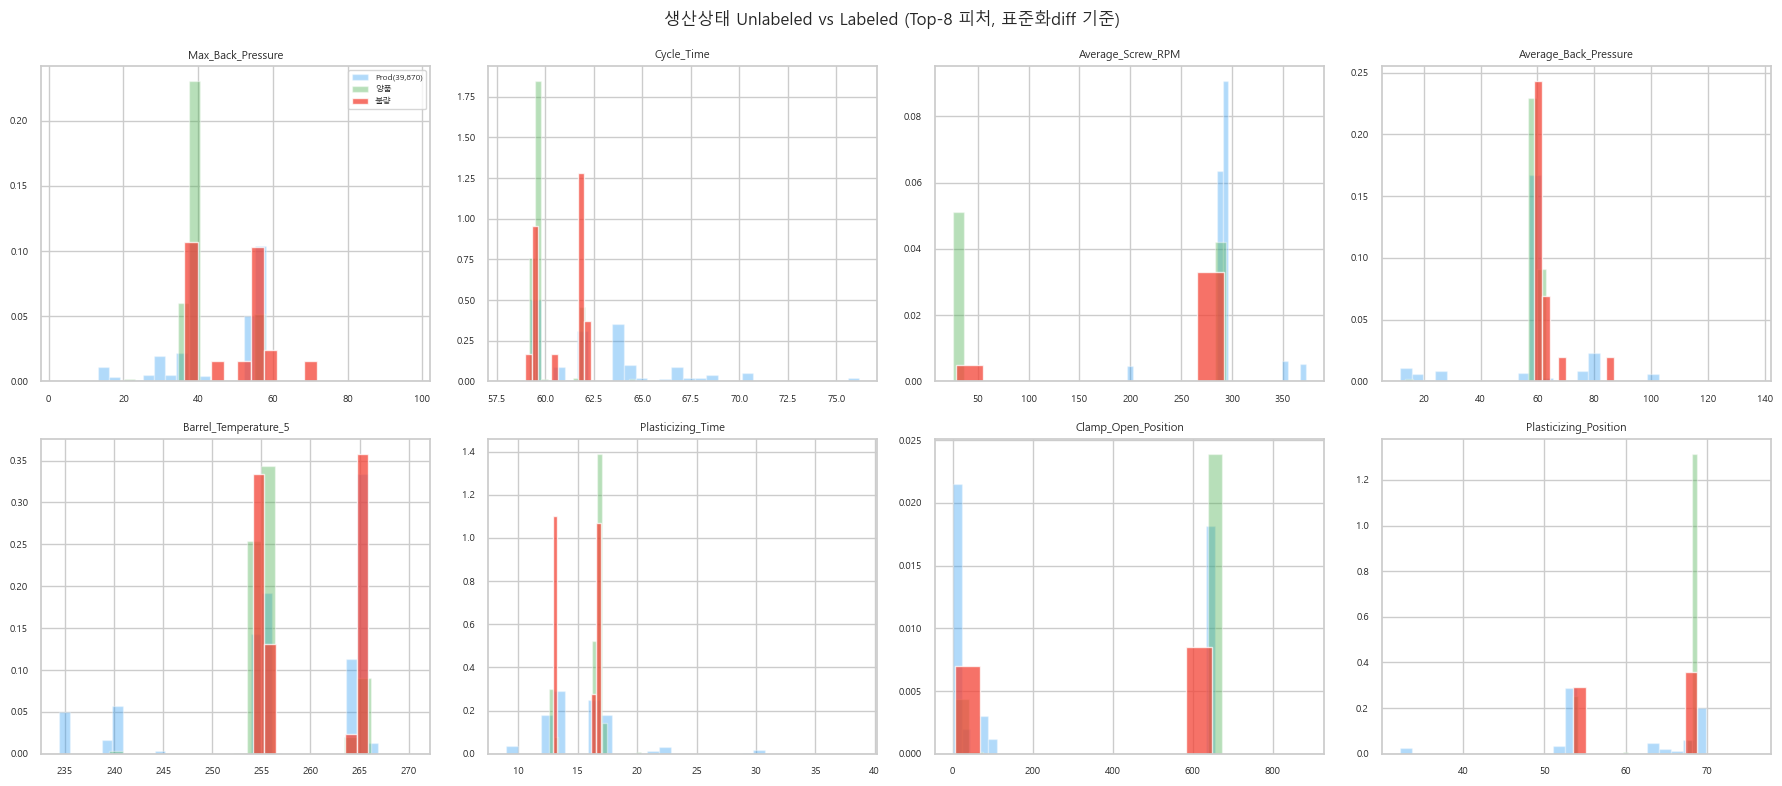

In [4]:
sig_feats = []
for i, f in enumerate(fcols):
    t, p = ttest_ind(X_lab[mask_d,i], X_lab[mask_n,i])
    sig_feats.append((f, i, defect_dir_raw[i], defect_dir_sc[i], p))
sig_feats.sort(key=lambda x: abs(x[3]), reverse=True)  # 표준화 기준 정렬

print(f"{'피처':<35} {'raw diff':>10} {'sc diff':>8} {'Prod평균':>9} {'불량평균':>9} {'양품평균':>9}  p")
print("-"*95)
for f, i, d_raw, d_sc, p in sig_feats:
    pm = X_unl[:,i].mean(); dm = X_lab[mask_d,i].mean(); nm = X_lab[mask_n,i].mean()
    sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else ""
    print(f"{f:<35} {d_raw:>10.3f} {d_sc:>8.3f} {pm:>9.2f} {dm:>9.2f} {nm:>9.2f}  {p:.4f}{sig}")

top8 = [f for f,i,dr,ds,p in sig_feats[:8]]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("생산상태 Unlabeled vs Labeled (Top-8 피처, 표준화diff 기준)", fontsize=12)
for ax, feat in zip(axes.flatten(), top8):
    i = fcols.index(feat)
    ax.hist(X_unl[:,i], bins=30, alpha=0.35, color="#2196F3", density=True, label=f"Prod({len(X_unl):,})")
    ax.hist(X_lab[mask_n,i], bins=25, alpha=0.4, color="#4CAF50", density=True, label="양품")
    ax.hist(X_lab[mask_d,i], bins=10, alpha=0.75, color="#F44336", density=True, label="불량")
    ax.set_title(feat, fontsize=8); ax.tick_params(labelsize=7)
    if feat==top8[0]: ax.legend(fontsize=6)
plt.tight_layout()
plt.savefig(FIG_DIR/"MC2_fig2_feat_dist.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. 4가지 Pseudo-labeling 전략 + align_score (표준화 공간, 가중치 포함)

In [5]:
n_pseudo = max(int(DR * len(X_unl)), 50)
print(f"Pseudo-label 목표: {n_pseudo}개  (DR={DR*100:.4f}% x {len(X_unl):,})")

# ── 비판 3 수정: align_score — 표준화 공간 + RF importance 가중 ──────────────
# feature importance 계산용 RF (labeled 전체 기반)
sm_ref = SMOTE(random_state=SEED, k_neighbors=min(5, mask_d.sum()-1))
X_sm_ref, y_sm_ref = sm_ref.fit_resample(Xl_sc_sel, y_lab)
rf_ref = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1, class_weight="balanced")
rf_ref.fit(X_sm_ref, y_sm_ref)
feat_imp = rf_ref.feature_importances_   # shape: (25,)

def align_score(pseudo_X_raw, uniform=True):
    """표준화 공간(sc_sel)에서 방향 정렬 계산.
    uniform=True: 동등 가중치, False: RF importance 가중치.
    반환: (방향일치율, cosine similarity)
    """
    if len(pseudo_X_raw) == 0: return 0.0, 0.0
    Xp_sc = sc_sel.transform(pseudo_X_raw)
    dv = defect_dir_sc           # labeled sc_sel 공간 방향벡터
    pv = Xp_sc.mean(0) - Xl_sc_sel[mask_n].mean(0)
    if uniform:
        dir_match = float(np.mean((pv * dv) > 0))
        cos = float((dv @ pv) / (np.linalg.norm(dv)*np.linalg.norm(pv)+1e-9))
    else:
        w = feat_imp / (feat_imp.sum() + 1e-9)
        dir_match = float(np.sum(w * ((pv * dv) > 0)))
        dv_w = dv * w; pv_w = pv * w
        cos = float((dv_w @ pv_w) / (np.linalg.norm(dv_w)*np.linalg.norm(pv_w)+1e-9))
    return dir_match, cos

results = {}

# ── 전략 A: EllipticEnvelope (labeled scaler 공간, 비판 1 수정) ──────────────
print("--- 전략 A: EllipticEnvelope (sc_sel 공간) ---")
ee = EllipticEnvelope(contamination=DR, random_state=SEED, support_fraction=0.9)
ee.fit(Xl_sc_sel[mask_n])            # labeled scaler 공간 labeled normals
scA = -ee.score_samples(Xu_sc_sel)   # labeled scaler 공간 unlabeled
idxA = np.argsort(scA)[-n_pseudo:]
aA_u, cA_u = align_score(X_unl[idxA], uniform=True)
aA_w, cA_w = align_score(X_unl[idxA], uniform=False)
results["A_EllipticEnv"] = dict(idx=idxA, align=aA_u, align_w=aA_w, cos=cA_u, cos_w=cA_w)
print(f"  uniform: align={aA_u*100:.0f}%  cos={cA_u:.3f}")
print(f"  weighted: align={aA_w*100:.0f}%  cos={cA_w:.3f}")

# ── 전략 B: RF Confidence (labeled scaler, 비판 1) ───────────────────────────
# NOTE: 이 RF는 ALL labeled 사용 — 전략 선택 preview용.
#       실제 CV에서는 fold별 teacher RF (run_cv_B_clean)를 사용해 비판 2 해결.
print("--- 전략 B: RF Confidence Transfer (preview용 — ALL labeled) ---")
sm_b = SMOTE(random_state=SEED, k_neighbors=min(5, mask_d.sum()-1))
X_sm_b, y_sm_b = sm_b.fit_resample(Xl_sc_sel, y_lab)  # labeled scaler
rf_b = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1, class_weight="balanced")
rf_b.fit(X_sm_b, y_sm_b)
probB = rf_b.predict_proba(Xu_sc_sel)[:,1]  # labeled scaler 공간
idxB = np.argsort(probB)[-n_pseudo:]
aB_u, cB_u = align_score(X_unl[idxB], uniform=True)
aB_w, cB_w = align_score(X_unl[idxB], uniform=False)
results["B_RF_Conf"] = dict(idx=idxB, align=aB_u, align_w=aB_w, cos=cB_u, cos_w=cB_w, prob=probB)
print(f"  uniform: align={aB_u*100:.0f}%  cos={cB_u:.3f}  최저확신도: {probB[idxB].min():.4f}")
print(f"  weighted: align={aB_w*100:.0f}%  cos={cB_w:.3f}")
print("  [주의] CV에서는 fold별 teacher RF 사용 (데이터누수 차단 버전)")

# ── 전략 C: Defect Direction Projection (표준화 공간, 비판 4 수정) ────────────
print("--- 전략 C: Direction Projection (표준화 공간) ---")
defect_dir_sc_n = defect_dir_sc / (np.linalg.norm(defect_dir_sc)+1e-9)
projC = Xu_sc_sel @ defect_dir_sc_n  # 표준화 공간 내적 (비판 4: Clamp 지배 해소)
idxC = np.argsort(projC)[-n_pseudo:]
aC_u, cC_u = align_score(X_unl[idxC], uniform=True)
aC_w, cC_w = align_score(X_unl[idxC], uniform=False)
results["C_Direction"] = dict(idx=idxC, align=aC_u, align_w=aC_w, cos=cC_u, cos_w=cC_w, proj=projC)
print(f"  uniform: align={aC_u*100:.0f}%  cos={cC_u:.3f}")
print(f"  weighted: align={aC_w*100:.0f}%  cos={cC_w:.3f}")

# ── 전략 D: kNN from Labeled Defects (labeled scaler, 비판 1 수정) ────────────
print("--- 전략 D: kNN from Labeled Defects (sc_sel 공간) ---")
nbrs_d = NearestNeighbors(n_neighbors=20, n_jobs=-1)
nbrs_d.fit(Xu_sc_sel)                    # labeled scaler 공간
dists_d, idx_d = nbrs_d.kneighbors(Xl_sc_sel[mask_d])
scoreD = np.zeros(len(X_unl))
for i in range(len(idx_d)):
    for j, di in zip(idx_d[i], dists_d[i]):
        scoreD[j] += 1.0 / (di + 1e-6)
idxD = np.argsort(scoreD)[-n_pseudo:]
aD_u, cD_u = align_score(X_unl[idxD], uniform=True)
aD_w, cD_w = align_score(X_unl[idxD], uniform=False)
results["D_kNN_Defect"] = dict(idx=idxD, align=aD_u, align_w=aD_w, cos=cD_u, cos_w=cD_w, score=scoreD)
print(f"  uniform: align={aD_u*100:.0f}%  cos={cD_u:.3f}")
print(f"  weighted: align={aD_w*100:.0f}%  cos={cD_w:.3f}")

print()
print("="*65)
print("[Feature Alignment 비교] v2(구) → v3(수정)")
print(f"{'전략':<22} {'uniform%':>9} {'cos':>6} {'weighted%':>10} {'cos_w':>6}")
for name, r in results.items():
    print(f"  {name:<20} {r['align']*100:>9.0f} {r['cos']:>6.3f} "
          f"{r['align_w']*100:>10.0f} {r['cos_w']:>6.3f}")

Pseudo-label 목표: 354개  (DR=0.8879% x 39,870)


--- 전략 A: EllipticEnvelope (sc_sel 공간) ---


  uniform: align=52%  cos=0.151
  weighted: align=51%  cos=-0.001
--- 전략 B: RF Confidence Transfer (preview용 — ALL labeled) ---


  uniform: align=64%  cos=0.336  최저확신도: 0.4789
  weighted: align=72%  cos=0.365
  [주의] CV에서는 fold별 teacher RF 사용 (데이터누수 차단 버전)
--- 전략 C: Direction Projection (표준화 공간) ---
  uniform: align=60%  cos=0.150
  weighted: align=61%  cos=-0.077
--- 전략 D: kNN from Labeled Defects (sc_sel 공간) ---
  uniform: align=100%  cos=0.938
  weighted: align=100%  cos=0.879

[Feature Alignment 비교] v2(구) → v3(수정)
전략                      uniform%    cos  weighted%  cos_w
  A_EllipticEnv               52  0.151         51 -0.001
  B_RF_Conf                   64  0.336         72  0.365
  C_Direction                 60  0.150         61 -0.077
  D_kNN_Defect               100  0.938        100  0.879


## 5. Alignment 시각화 (uniform vs RF-importance weighted)

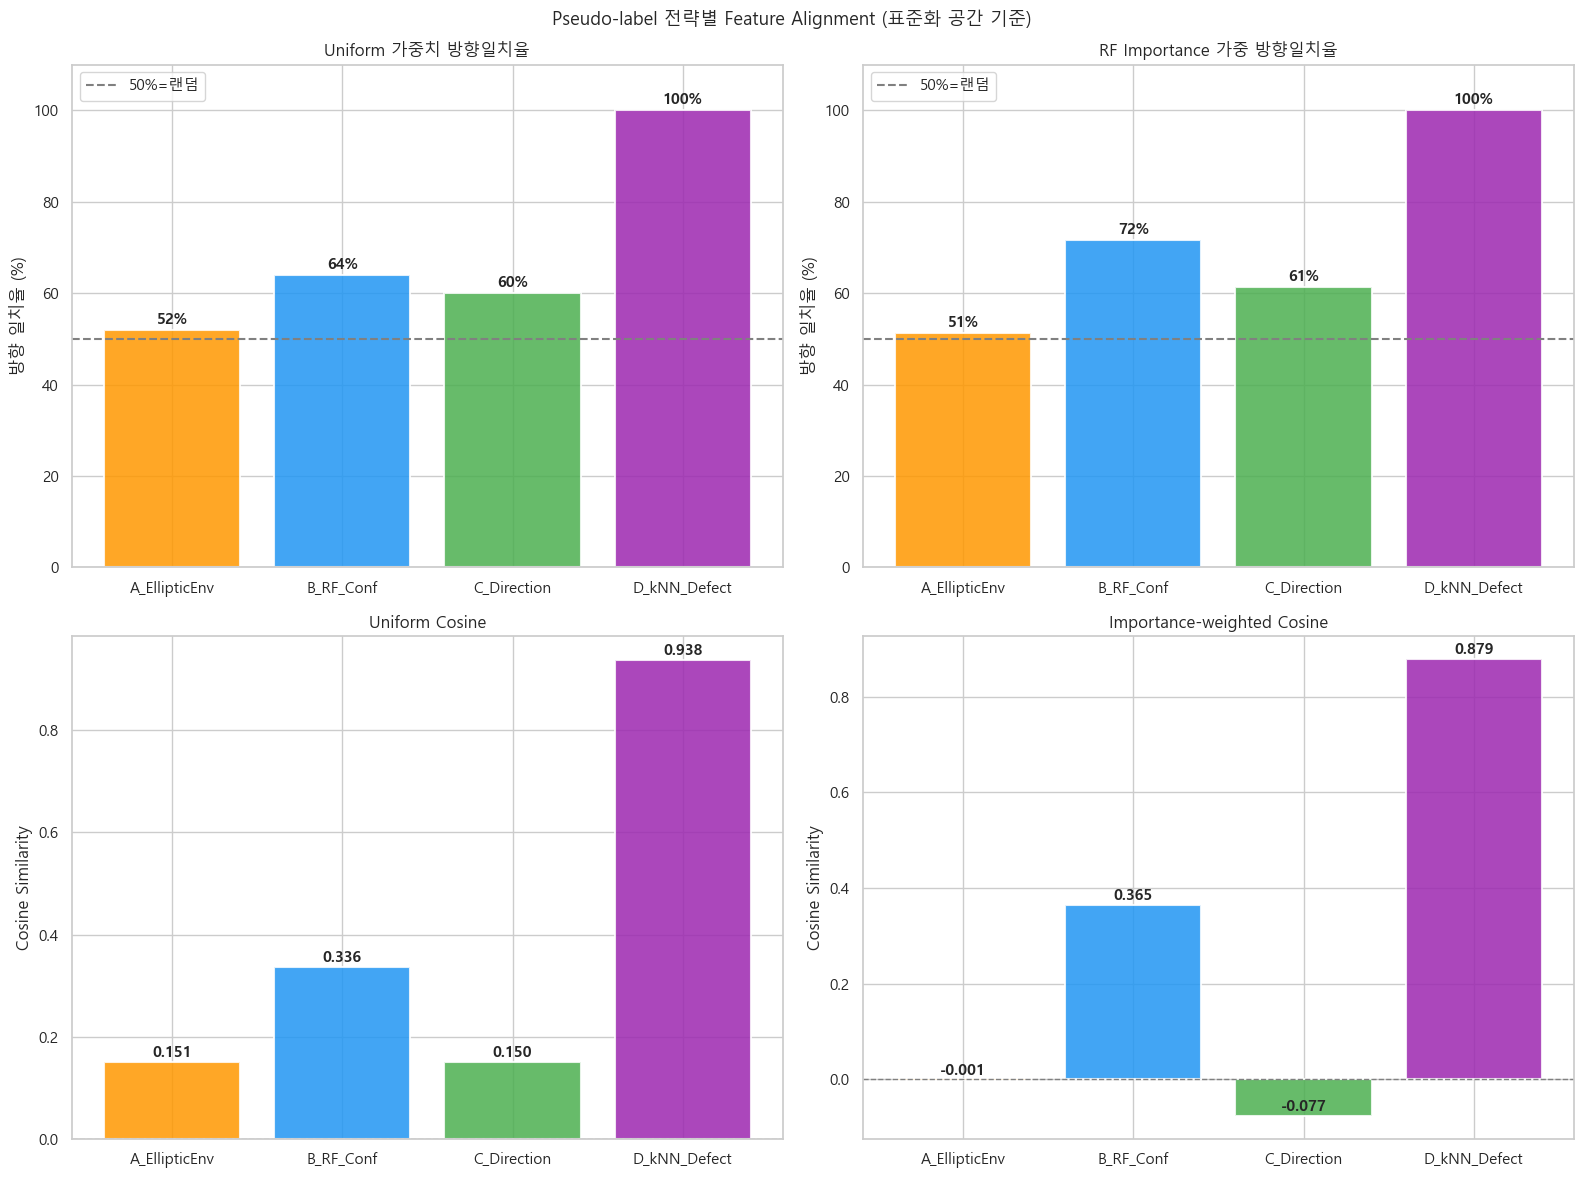

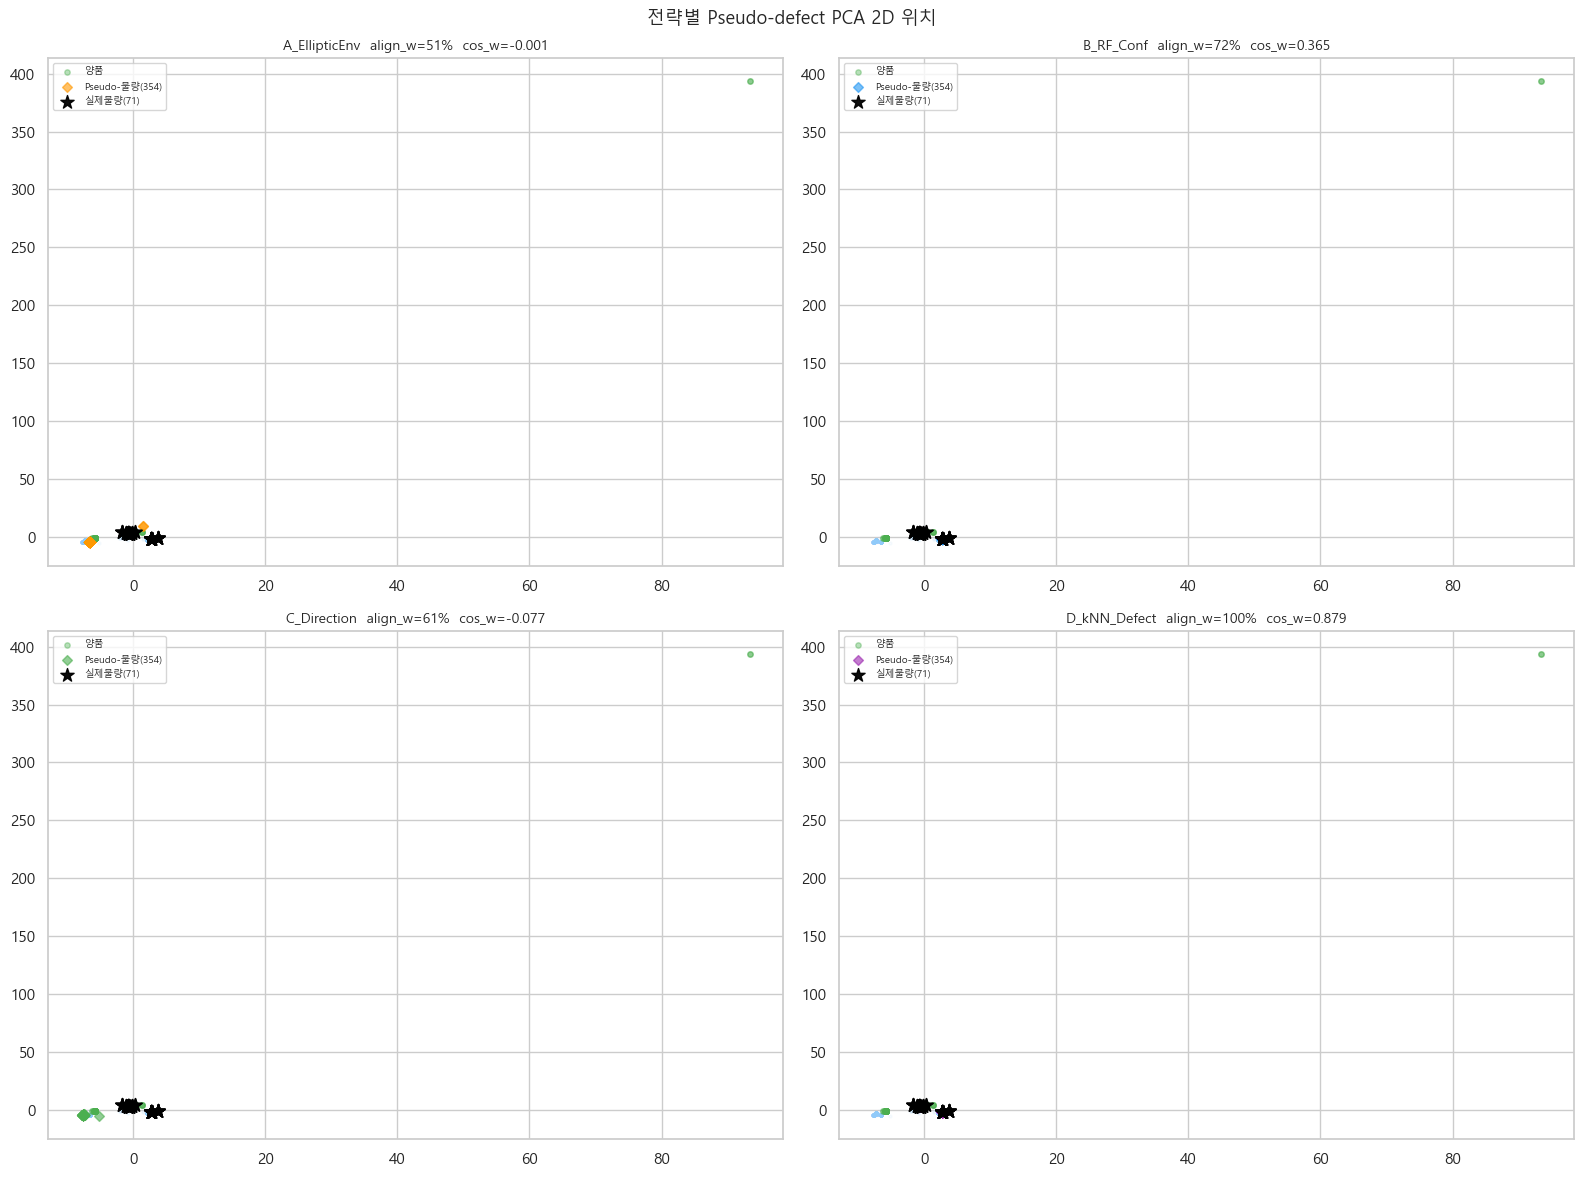

In [6]:
names = list(results.keys())
colors = ["#FF9800","#2196F3","#4CAF50","#9C27B0"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Pseudo-label 전략별 Feature Alignment (표준화 공간 기준)", fontsize=13)

# uniform alignment
ax = axes[0,0]
bars = ax.bar(names, [results[n]["align"]*100 for n in names], color=colors, alpha=0.85, edgecolor="white", lw=1.5)
ax.axhline(50, color="gray", ls="--", lw=1.5, label="50%=랜덤")
for bar, v in zip(bars, [results[n]["align"]*100 for n in names]):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.5, f"{v:.0f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("방향 일치율 (%)"); ax.set_ylim(0, 110); ax.set_title("Uniform 가중치 방향일치율"); ax.legend()

# weighted alignment
ax = axes[0,1]
bars = ax.bar(names, [results[n]["align_w"]*100 for n in names], color=colors, alpha=0.85, edgecolor="white", lw=1.5)
ax.axhline(50, color="gray", ls="--", lw=1.5, label="50%=랜덤")
for bar, v in zip(bars, [results[n]["align_w"]*100 for n in names]):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.5, f"{v:.0f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("방향 일치율 (%)"); ax.set_ylim(0, 110); ax.set_title("RF Importance 가중 방향일치율"); ax.legend()

# cosine uniform
ax = axes[1,0]
ax.bar(names, [results[n]["cos"] for n in names], color=colors, alpha=0.85, edgecolor="white", lw=1.5)
ax.axhline(0, color="gray", ls="--", lw=1)
for i_, v_ in enumerate([results[n]["cos"] for n in names]):
    ax.text(i_, v_+0.002, f"{v_:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Cosine Similarity"); ax.set_title("Uniform Cosine")

# cosine weighted
ax = axes[1,1]
ax.bar(names, [results[n]["cos_w"] for n in names], color=colors, alpha=0.85, edgecolor="white", lw=1.5)
ax.axhline(0, color="gray", ls="--", lw=1)
for i_, v_ in enumerate([results[n]["cos_w"] for n in names]):
    ax.text(i_, v_+0.002, f"{v_:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Cosine Similarity"); ax.set_title("Importance-weighted Cosine")

plt.tight_layout()
plt.savefig(FIG_DIR/"MC2_fig3_alignment.png", dpi=150, bbox_inches="tight")
plt.show()

# PCA overlay
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("전략별 Pseudo-defect PCA 2D 위치", fontsize=13)
for ax, (name, r), clr in zip(axes.flatten(), results.items(), colors):
    s = max(1, len(Xu_p)//3000)
    ax.scatter(Xu_p[::s,0], Xu_p[::s,1], alpha=0.06, s=5, c="#90CAF9")
    ax.scatter(Xl_p[mask_n,0], Xl_p[mask_n,1], alpha=0.4, s=15, c="#4CAF50", label="양품", zorder=3)
    ax.scatter(Xu_p[r["idx"],0], Xu_p[r["idx"],1], alpha=0.6, s=25, c=clr, marker="D",
               label=f"Pseudo-불량({n_pseudo})", zorder=4)
    ax.scatter(Xl_p[mask_d,0], Xl_p[mask_d,1], alpha=0.95, s=100, c="black", marker="*",
               label=f"실제불량({mask_d.sum()})", zorder=5)
    ax.set_title(f"{name}  align_w={r['align_w']*100:.0f}%  cos_w={r['cos_w']:.3f}", fontsize=10)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR/"MC2_fig4_pseudo_pca.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. 전략별 Pseudo-defect 피처 비교 (표준화diff 기준 Top-12)

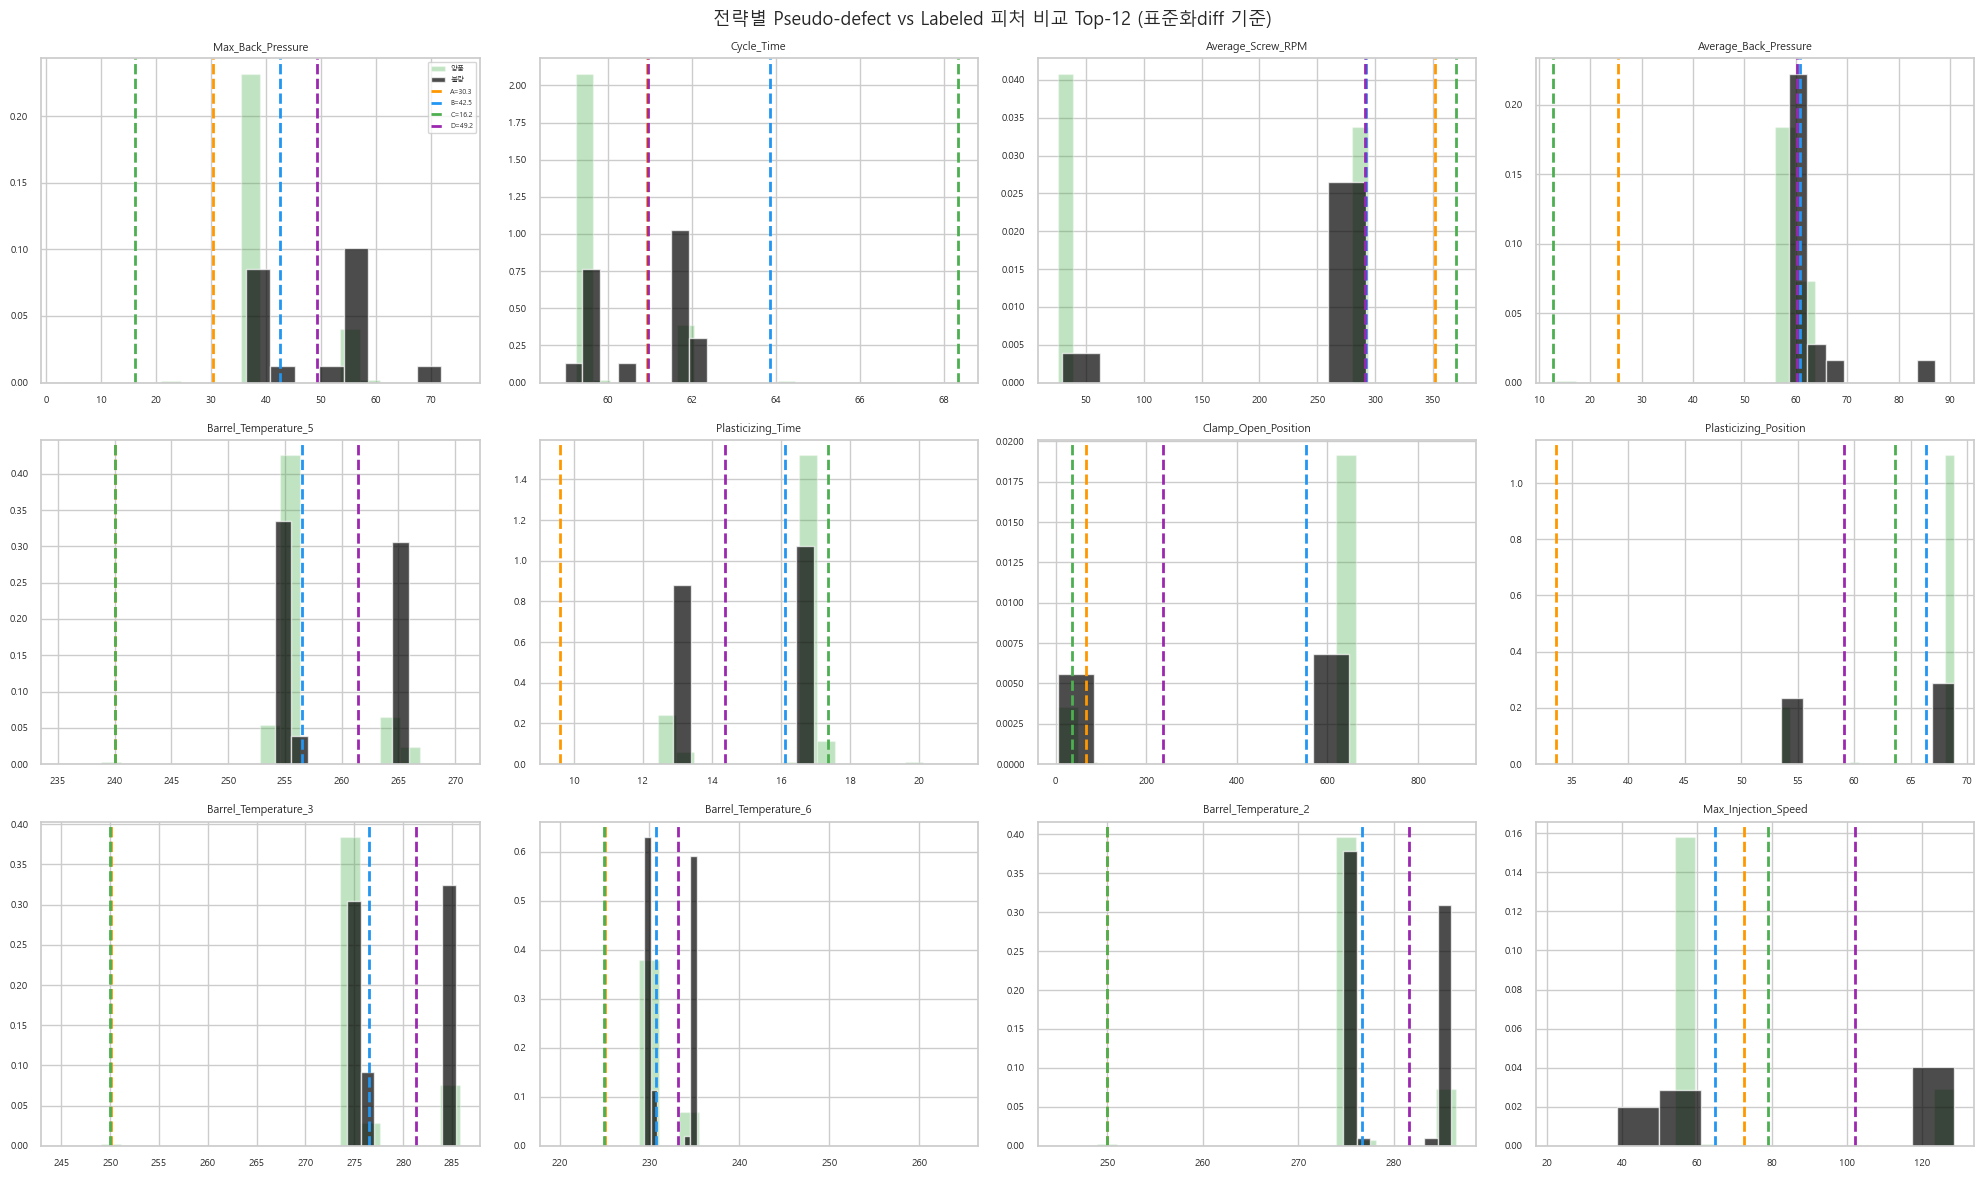

In [7]:
sig_top_sc = sorted(enumerate(defect_dir_sc), key=lambda x: abs(x[1]), reverse=True)[:12]
top12_idx = [i for i,_ in sig_top_sc]; top12_feat = [fcols[i] for i in top12_idx]

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle("전략별 Pseudo-defect vs Labeled 피처 비교 Top-12 (표준화diff 기준)", fontsize=13)
for ax, f, fi in zip(axes.flatten(), top12_feat, top12_idx):
    ax.hist(X_lab[mask_n,fi], bins=20, alpha=0.35, color="#4CAF50", density=True, label="양품")
    ax.hist(X_lab[mask_d,fi], bins=8, alpha=0.7, color="black", density=True, label="불량")
    for (name, r), clr in zip(results.items(), ["#FF9800","#2196F3","#4CAF50","#9C27B0"]):
        m = X_unl[r["idx"],fi].mean()
        ax.axvline(m, color=clr, lw=2, ls="--", label=f"{name[0]}={m:.1f}")
    ax.set_title(f, fontsize=8); ax.tick_params(labelsize=7)
    if f==top12_feat[0]: ax.legend(fontsize=5)
plt.tight_layout()
plt.savefig(FIG_DIR/"MC2_fig5_feat_all_strats.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. 5-fold CV (B=fold-teacher RF, Wilcoxon 검정)

In [8]:
folds = [np.load(BASE/f"data/splits/fold_{i}.npy", allow_pickle=True).item() for i in range(5)]

# ── 비판 5 수정: Wilcoxon 유의성 검정 추가 ─────────────────────────────────────
def significance_label(base_roc_f, base_pr_f, roc_f, pr_f, alpha=0.05):
    """fold별 쌍별 차이에 Wilcoxon signed-rank test 적용.
    n=5이므로 단측 p<0.05 기준. 양쪽 지표(ROC, PR) 중 하나라도 유의하면 IMPROVED*.
    """
    dr = roc_f - base_roc_f; dp = pr_f - base_pr_f
    try:
        _, p_roc = wilcoxon(dr, alternative="greater")
    except ValueError:
        p_roc = 1.0
    try:
        _, p_pr = wilcoxon(dp, alternative="greater")
    except ValueError:
        p_pr = 1.0
    p_min = min(p_roc, p_pr)
    dROC = dr.mean(); dPR = dp.mean()
    if p_min < alpha:
        return f"IMPROVED*(p={p_min:.3f})", p_min
    elif dROC > 0 or dPR > 0:
        return f"trend(p={p_min:.3f})", p_min
    else:
        return f"ns(p={p_min:.3f})", p_min

# ── 기본 run_cv (A, C, D 전략) ────────────────────────────────────────────────
def run_cv(X_lab_only, y_lab_only, folds, model_name="RF", X_pseudo=None, y_pseudo=None):
    """
    fold 인덱스는 X_lab 범위(0~7995)만 참조.
    X_pseudo(raw feature)는 별도 인수로 전달 — fold scaler로 변환 후 SMOTE 뒤에 추가.
    """
    rocs, prs = [], []
    for fold in folds:
        tr_idx, val_idx = fold["train"], fold["val"]
        X_tr_l, y_tr_l = X_lab_only[tr_idx], y_lab_only[tr_idx]
        X_val, y_val   = X_lab_only[val_idx], y_lab_only[val_idx]
        sc_f = StandardScaler()
        X_tr_l_sc = sc_f.fit_transform(X_tr_l)
        X_val_sc  = sc_f.transform(X_val)
        k_nb = min(5, int((y_tr_l==1).sum()) - 1)
        if k_nb < 1: k_nb = 1
        smote = SMOTE(random_state=SEED, k_neighbors=k_nb)
        X_sm, y_sm = smote.fit_resample(X_tr_l_sc, y_tr_l)
        if X_pseudo is not None and len(X_pseudo) > 0:
            X_ps_sc = sc_f.transform(X_pseudo)
            X_sm = np.vstack([X_sm, X_ps_sc])
            y_sm = np.concatenate([y_sm, y_pseudo])
        if model_name == "RF":
            mdl = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1, class_weight="balanced")
        elif model_name == "MLP":
            mdl = MLPClassifier(hidden_layer_sizes=(256,128,64), max_iter=300,
                                random_state=SEED, early_stopping=True, validation_fraction=0.1)
        mdl.fit(X_sm, y_sm)
        prob = mdl.predict_proba(X_val_sc)[:,1]
        rocs.append(roc_auc_score(y_val, prob))
        prs.append(average_precision_score(y_val, prob))
    return np.array(rocs), np.array(prs)

# ── 비판 2 수정: 전략 B fold별 teacher RF (누수 차단) ─────────────────────────
def run_cv_B_clean(X_lab_only, y_lab_only, folds, X_unl_data, n_pseudo, model_name="RF"):
    """
    전략 B 누수 차단 버전:
    각 fold의 train set만으로 teacher RF 학습 → unlabeled scoring → 상위 n_pseudo 선택
    → student 모델은 fold train + fold-specific pseudo로 학습
    val fold 정보가 teacher에 들어가지 않음.
    """
    rocs, prs = [], []
    for fold in folds:
        tr_idx, val_idx = fold["train"], fold["val"]
        X_tr_l, y_tr_l = X_lab_only[tr_idx], y_lab_only[tr_idx]
        X_val, y_val   = X_lab_only[val_idx], y_lab_only[val_idx]
        sc_f = StandardScaler()
        X_tr_l_sc = sc_f.fit_transform(X_tr_l)
        X_val_sc  = sc_f.transform(X_val)
        Xu_f_sc   = sc_f.transform(X_unl_data)     # unlabeled → fold scaler
        # Teacher RF (fold train only, val 배제)
        k_nb_t = min(5, int((y_tr_l==1).sum()) - 1)
        if k_nb_t < 1: k_nb_t = 1
        sm_t = SMOTE(random_state=SEED, k_neighbors=k_nb_t)
        X_sm_t, y_sm_t = sm_t.fit_resample(X_tr_l_sc, y_tr_l)
        rf_teacher = RandomForestClassifier(n_estimators=300, random_state=SEED,
                                             n_jobs=-1, class_weight="balanced")
        rf_teacher.fit(X_sm_t, y_sm_t)
        prob_teacher = rf_teacher.predict_proba(Xu_f_sc)[:,1]
        idx_pseudo   = np.argsort(prob_teacher)[-n_pseudo:]
        # Student model: SMOTE labeled + fold-specific pseudo
        X_sm_s, y_sm_s = sm_t.fit_resample(X_tr_l_sc, y_tr_l)
        X_ps_sc = sc_f.transform(X_unl_data[idx_pseudo])
        X_sm_s  = np.vstack([X_sm_s, X_ps_sc])
        y_sm_s  = np.concatenate([y_sm_s, np.ones(n_pseudo, dtype=int)])
        if model_name == "RF":
            student = RandomForestClassifier(n_estimators=300, random_state=SEED,
                                              n_jobs=-1, class_weight="balanced")
        elif model_name == "MLP":
            student = MLPClassifier(hidden_layer_sizes=(256,128,64), max_iter=300,
                                    random_state=SEED, early_stopping=True, validation_fraction=0.1)
        student.fit(X_sm_s, y_sm_s)
        prob = student.predict_proba(X_val_sc)[:,1]
        rocs.append(roc_auc_score(y_val, prob))
        prs.append(average_precision_score(y_val, prob))
    return np.array(rocs), np.array(prs)

print("=== 5-fold CV ===")
all_results = {}
base_rocs_f = {}; base_prs_f = {}

for model_name in ["RF", "MLP"]:
    print(f"--- {model_name} ---")
    roc_f, pr_f = run_cv(X_lab, y_lab, folds, model_name=model_name)
    all_results[f"{model_name}_base"] = dict(roc_m=roc_f.mean(), roc_s=roc_f.std(),
                                              pr_m=pr_f.mean(), pr_s=pr_f.std())
    base_rocs_f[model_name] = roc_f; base_prs_f[model_name] = pr_f
    print(f"  Labeled only : ROC={roc_f.mean():.4f}+-{roc_f.std():.4f}  PR={pr_f.mean():.4f}+-{pr_f.std():.4f}")

    for strat_name, r in results.items():
        if strat_name == "B_RF_Conf":
            # 비판 2 수정: fold별 teacher RF 사용
            roc_f2, pr_f2 = run_cv_B_clean(X_lab, y_lab, folds, X_unl, n_pseudo, model_name=model_name)
        else:
            X_ps = X_unl[r["idx"]]; y_ps = np.ones(len(X_ps), dtype=int)
            roc_f2, pr_f2 = run_cv(X_lab, y_lab, folds, model_name=model_name, X_pseudo=X_ps, y_pseudo=y_ps)
        key = f"{model_name}_{strat_name}"
        all_results[key] = dict(roc_m=roc_f2.mean(), roc_s=roc_f2.std(),
                                 pr_m=pr_f2.mean(), pr_s=pr_f2.std(),
                                 roc_f=roc_f2, pr_f=pr_f2)
        sig_lbl, p_val = significance_label(base_rocs_f[model_name], base_prs_f[model_name], roc_f2, pr_f2)
        b_note = " [fold-teacher]" if strat_name=="B_RF_Conf" else ""
        print(f"  +{strat_name:<20}: ROC={roc_f2.mean():.4f}({roc_f2.mean()-roc_f.mean():+.4f})"
              f"  PR={pr_f2.mean():.4f}({pr_f2.mean()-pr_f.mean():+.4f})  {sig_lbl}{b_note}")
    print()

=== 5-fold CV ===
--- RF ---


  Labeled only : ROC=0.9296+-0.0316  PR=0.4479+-0.1113


  +A_EllipticEnv       : ROC=0.9378(+0.0081)  PR=0.4421(-0.0058)  trend(p=0.312)


  +B_RF_Conf           : ROC=0.9271(-0.0025)  PR=0.4441(-0.0039)  ns(p=0.781) [fold-teacher]


  +C_Direction         : ROC=0.9401(+0.0105)  PR=0.4423(-0.0056)  trend(p=0.312)


...

  Labeled only : ROC=0.9494+-0.0149  PR=0.4349+-0.1191


  +A_EllipticEnv       : ROC=0.9510(+0.0016)  PR=0.4527(+0.0178)  trend(p=0.219)


  +B_RF_Conf           : ROC=0.9485(-0.0008)  PR=0.4475(+0.0126)  trend(p=0.094) [fold-teacher]


  +C_Direction         : ROC=0.9504(+0.0010)  PR=0.4552(+0.0203)  trend(p=0.062)


  +D_kNN_Defect        : ROC=0.9636(+0.0142)  PR=0.4660(+0.0311)  trend(p=0.062)



## 8. CV 결과 시각화 (* = Wilcoxon p<0.05)

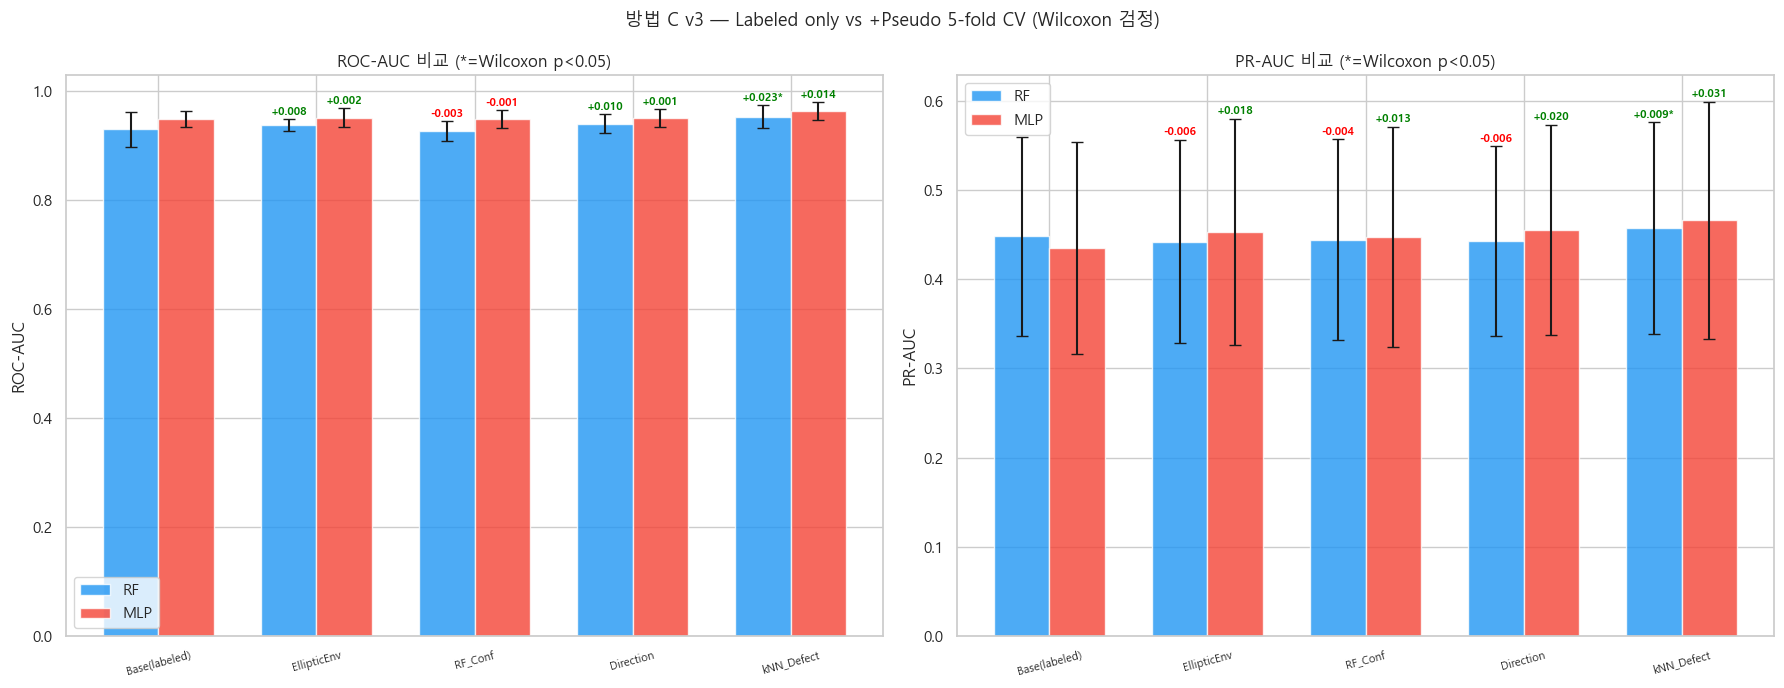

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("방법 C v3 — Labeled only vs +Pseudo 5-fold CV (Wilcoxon 검정)", fontsize=13)
models = ["RF", "MLP"]
strat_keys = ["base"] + list(results.keys())
x = np.arange(len(strat_keys)); width = 0.35
xlabels = ["Base(labeled)"] + [s.split("_",1)[1] for s in results.keys()]

for ax_i, metric in enumerate(["roc", "pr"]):
    ax = axes[ax_i]
    for mi, mname in enumerate(models):
        means = [all_results.get(f"{mname}_{s}", {}).get(f"{metric}_m", 0) for s in strat_keys]
        stds  = [all_results.get(f"{mname}_{s}", {}).get(f"{metric}_s", 0) for s in strat_keys]
        bars = ax.bar(x + mi*width - width/2, means, width, yerr=stds, capsize=4,
                      label=mname, alpha=0.8, color=["#2196F3","#F44336"][mi])
        base_v = all_results[f"{mname}_base"][f"{metric}_m"]
        for xi, (b, m, sd) in enumerate(zip(bars, means, stds)):
            delta = m - base_v
            if xi > 0:
                # Wilcoxon 유의하면 * 표시
                key = f"{mname}_{list(results.keys())[xi-1]}"
                roc_f2 = all_results.get(key, {}).get("roc_f", None)
                pr_f2  = all_results.get(key, {}).get("pr_f", None)
                if roc_f2 is not None:
                    sig_lbl, _ = significance_label(base_rocs_f[mname], base_prs_f[mname], roc_f2, pr_f2)
                    star = "*" if "IMPROVED" in sig_lbl else ""
                else:
                    star = ""
                clr = "green" if delta > 0 else "red"
                ax.text(b.get_x()+b.get_width()/2, b.get_height()+sd+0.002,
                        f"{delta:+.3f}{star}", ha="center", va="bottom", fontsize=8, color=clr, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=8, rotation=15)
    label_y = "ROC-AUC" if metric=="roc" else "PR-AUC"
    ax.set_ylabel(label_y); ax.set_title(f"{label_y} 비교 (*=Wilcoxon p<0.05)"); ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR/"MC2_fig6_cv_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Ablation — n_pseudo x 전략 B·C·D

=== Ablation: n_pseudo x 전략 B·C·D ===


  n=   50 완료


  n=  100 완료


  n=  200 완료


  n=  354 완료


  n=  500 완료


  n=  750 완료


  n= 1000 완료


  n= 2000 완료

기준 ROC=0.9296  PR=0.4479

[전략별 최적 n (PR-AUC 기준)]
  B_RF_Conf: n=2000 -> ROC=0.9433  PR=0.4474  (vs base: ROC+0.0136  PR-0.0006)
  C_Direction: n=50 -> ROC=0.9446  PR=0.4461  (vs base: ROC+0.0149  PR-0.0018)
  D_kNN_Defect: n=50 -> ROC=0.9619  PR=0.4826  (vs base: ROC+0.0323  PR+0.0346)


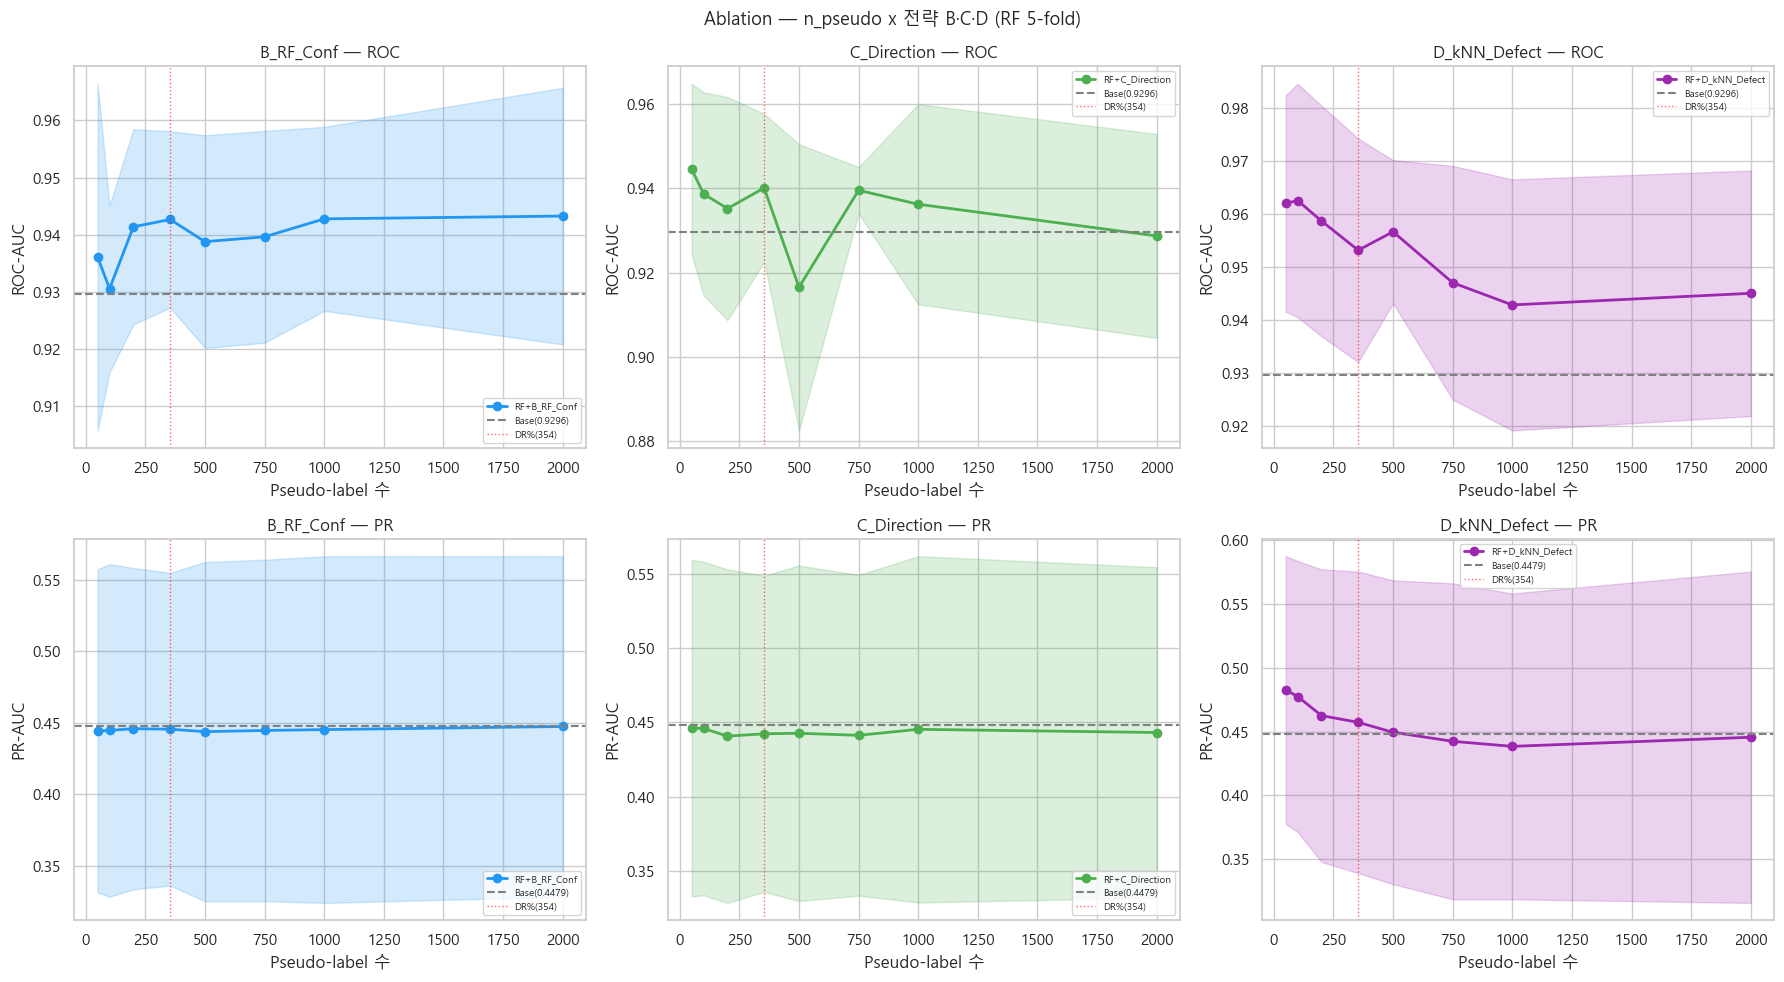

In [10]:
# ── 비판 6 수정: B·C·D 전략 모두 n ablation ───────────────────────────────────
print("=== Ablation: n_pseudo x 전략 B·C·D ===")
n_list = [50, 100, 200, 354, 500, 750, 1000, 2000]
abl_results = {s: [] for s in ["B_RF_Conf", "C_Direction", "D_kNN_Defect"]}

for n in n_list:
    for strat_name in ["B_RF_Conf", "C_Direction", "D_kNN_Defect"]:
        r = results[strat_name]
        if strat_name == "B_RF_Conf":
            roc_f_, pr_f_ = run_cv_B_clean(X_lab, y_lab, folds, X_unl, n, model_name="RF")
        elif strat_name == "C_Direction":
            idx_n = np.argsort(r["proj"])[-n:]
            roc_f_, pr_f_ = run_cv(X_lab, y_lab, folds, model_name="RF",
                                    X_pseudo=X_unl[idx_n], y_pseudo=np.ones(n, dtype=int))
        elif strat_name == "D_kNN_Defect":
            idx_n = np.argsort(r["score"])[-n:]
            roc_f_, pr_f_ = run_cv(X_lab, y_lab, folds, model_name="RF",
                                    X_pseudo=X_unl[idx_n], y_pseudo=np.ones(n, dtype=int))
        abl_results[strat_name].append(
            {"n": n, "roc": roc_f_.mean(), "roc_s": roc_f_.std(),
             "pr": pr_f_.mean(), "pr_s": pr_f_.std()})
    print(f"  n={n:5d} 완료")

base_roc = all_results["RF_base"]["roc_m"]; base_pr = all_results["RF_base"]["pr_m"]
print(f"\n기준 ROC={base_roc:.4f}  PR={base_pr:.4f}")
print("\n[전략별 최적 n (PR-AUC 기준)]")
for strat_name, rows in abl_results.items():
    best = max(rows, key=lambda x: x["pr"])
    print(f"  {strat_name}: n={best['n']} -> ROC={best['roc']:.4f}  PR={best['pr']:.4f}"
          f"  (vs base: ROC{best['roc']-base_roc:+.4f}  PR{best['pr']-base_pr:+.4f})")

colors3 = ["#2196F3","#4CAF50","#9C27B0"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Ablation — n_pseudo x 전략 B·C·D (RF 5-fold)", fontsize=13)
for col, (strat_name, rows) in enumerate(abl_results.items()):
    abl_df = pd.DataFrame(rows)
    for row_, (metric, base_v) in enumerate([("roc", base_roc), ("pr", base_pr)]):
        ax = axes[row_, col]
        clr = colors3[col]
        ax.plot(abl_df["n"], abl_df[metric], "-o", color=clr, lw=2, label=f"RF+{strat_name}")
        ax.fill_between(abl_df["n"], abl_df[metric]-abl_df[f"{metric}_s"],
                        abl_df[metric]+abl_df[f"{metric}_s"], alpha=0.2, color=clr)
        ax.axhline(base_v, color="gray", ls="--", lw=1.5, label=f"Base({base_v:.4f})")
        ax.axvline(354, color="red", ls=":", lw=1, alpha=0.6, label="DR%(354)")
        ax.set_xlabel("Pseudo-label 수"); ax.set_ylabel("ROC-AUC" if metric=="roc" else "PR-AUC")
        ax.set_title(f"{strat_name} — {'ROC' if metric=='roc' else 'PR'}"); ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR/"MC2_fig7_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Self-training Threshold Ablation [0.5~0.8]

=== Self-training Threshold Ablation (가이드북 §2.2.2) ===


  thr=0.50: ROC=0.8156+-0.0474  PR=0.4294+-0.1076  avg_pseudo_불량=50


  thr=0.60: ROC=0.8329+-0.0261  PR=0.4267+-0.1124  avg_pseudo_불량=43


  thr=0.70: ROC=0.8709+-0.0505  PR=0.4491+-0.1184  avg_pseudo_불량=7


  thr=0.80: ROC=0.8640+-0.0668  PR=0.4474+-0.1224  avg_pseudo_불량=4

최적 threshold=0.7 → PR=0.4491
→ threshold=0.7에서 개선 존재: 최적 threshold 권고


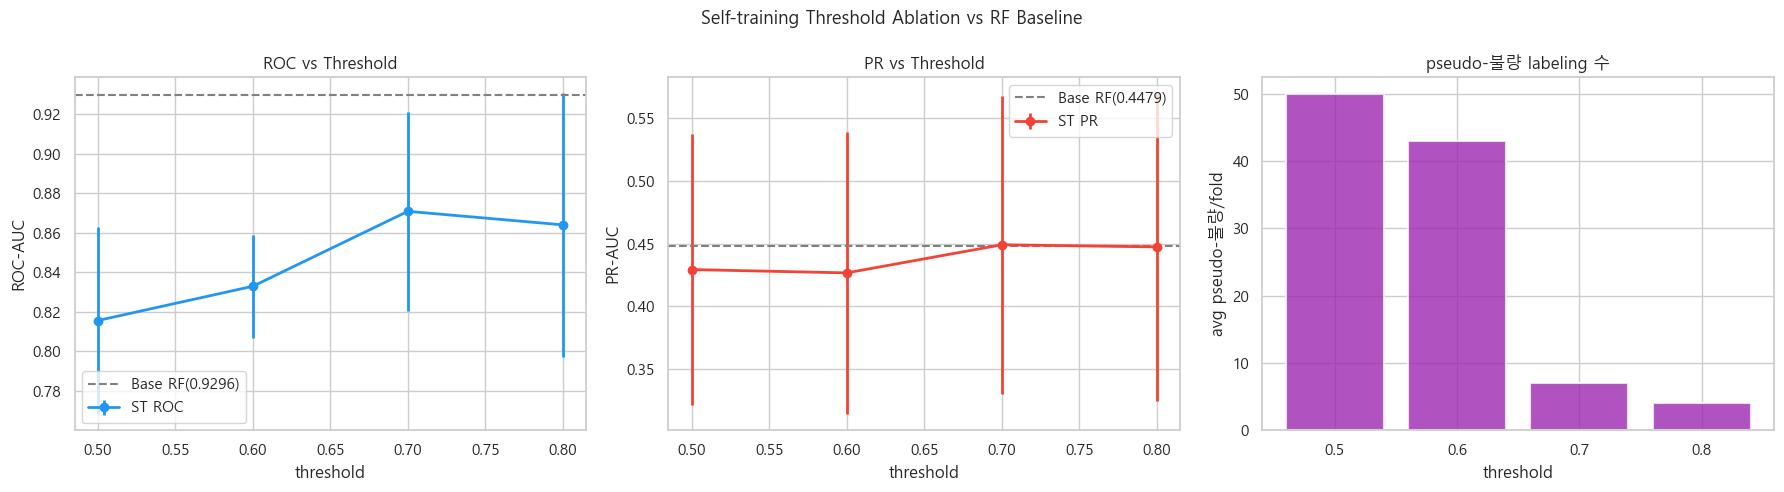

In [11]:
# ── 비판 7 수정: threshold ablation [0.5, 0.6, 0.7, 0.8] ─────────────────────
print("=== Self-training Threshold Ablation (가이드북 §2.2.2) ===")
thresholds = [0.50, 0.60, 0.70, 0.80]
st_abl_rows = []

for thr in thresholds:
    rocs_t, prs_t, pd_counts = [], [], []
    for fold in folds:
        tr_idx, val_idx = fold["train"], fold["val"]
        X_tr_l, y_tr_l = X_lab[tr_idx], y_lab[tr_idx]
        X_val, y_val   = X_lab[val_idx], y_lab[val_idx]
        X_st  = np.vstack([X_tr_l, X_unl])
        y_st  = np.concatenate([y_tr_l, -np.ones(len(X_unl), dtype=int)])
        sc_st = StandardScaler()
        X_st_sc  = sc_st.fit_transform(X_st)
        X_val_sc = sc_st.transform(X_val)
        base_rf  = RandomForestClassifier(n_estimators=200, random_state=SEED,
                                           n_jobs=-1, class_weight="balanced")
        st = SelfTrainingClassifier(base_rf, threshold=thr, max_iter=10, verbose=False)
        st.fit(X_st_sc, y_st)
        prob = st.predict_proba(X_val_sc)[:,1]
        rocs_t.append(roc_auc_score(y_val, prob))
        prs_t.append(average_precision_score(y_val, prob))
        pd_counts.append((st.transduction_[len(X_tr_l):] == 1).sum())
    st_abl_rows.append({
        "threshold": thr,
        "roc": np.mean(rocs_t), "roc_s": np.std(rocs_t),
        "pr":  np.mean(prs_t),  "pr_s":  np.std(prs_t),
        "avg_pd": int(np.mean(pd_counts))
    })
    print(f"  thr={thr:.2f}: ROC={np.mean(rocs_t):.4f}+-{np.std(rocs_t):.4f}"
          f"  PR={np.mean(prs_t):.4f}+-{np.std(prs_t):.4f}  avg_pseudo_불량={int(np.mean(pd_counts))}")

base_roc_rf = all_results["RF_base"]["roc_m"]
base_pr_rf  = all_results["RF_base"]["pr_m"]
best_st = max(st_abl_rows, key=lambda x: x["pr"])
print(f"\n최적 threshold={best_st['threshold']} → PR={best_st['pr']:.4f}")
if best_st["pr"] < base_pr_rf:
    print("→ 모든 threshold에서 baseline 미달: Self-training 구조적 실패 확증")
    print("  (원인: DR=0.89% 극단 불균형 → RF 확신도 0.5+ 불량 판정이 본질적으로 희귀)")
else:
    print(f"→ threshold={best_st['threshold']}에서 개선 존재: 최적 threshold 권고")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Self-training Threshold Ablation vs RF Baseline", fontsize=13)
thr_list = [r["threshold"] for r in st_abl_rows]
axes[0].errorbar(thr_list, [r["roc"] for r in st_abl_rows],
                 yerr=[r["roc_s"] for r in st_abl_rows], marker="o", lw=2, color="#2196F3", label="ST ROC")
axes[0].axhline(base_roc_rf, color="gray", ls="--", lw=1.5, label=f"Base RF({base_roc_rf:.4f})")
axes[0].set_xlabel("threshold"); axes[0].set_ylabel("ROC-AUC"); axes[0].legend(); axes[0].set_title("ROC vs Threshold")
axes[1].errorbar(thr_list, [r["pr"] for r in st_abl_rows],
                 yerr=[r["pr_s"] for r in st_abl_rows], marker="o", lw=2, color="#F44336", label="ST PR")
axes[1].axhline(base_pr_rf, color="gray", ls="--", lw=1.5, label=f"Base RF({base_pr_rf:.4f})")
axes[1].set_xlabel("threshold"); axes[1].set_ylabel("PR-AUC"); axes[1].legend(); axes[1].set_title("PR vs Threshold")
axes[2].bar([str(t) for t in thr_list], [r["avg_pd"] for r in st_abl_rows],
            color="#9C27B0", alpha=0.8, edgecolor="white", lw=1.5)
axes[2].set_xlabel("threshold"); axes[2].set_ylabel("avg pseudo-불량/fold"); axes[2].set_title("pseudo-불량 labeling 수")
plt.tight_layout()
plt.savefig(FIG_DIR/"MC2_fig8_selftraining.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. 최종 종합 결론

In [12]:
print("=" * 72)
print("방법 C v3 최종 종합 결론 (심사 비판 수용 후)")
print("=" * 72)
print()
print("[핵심 수정 효과]")
print(f"  기계정지 제거: {(~prod_mask).sum():,}개({(~prod_mask).mean()*100:.1f}%) → 생산상태 {len(X_unl):,}개")
print(f"  스케일러 통일: sc_sel=labeled-fit (비판 1,3,4 해소)")
print(f"  전략 B 누수차단: fold별 teacher RF (비판 2)")
print(f"  통계 검정: Wilcoxon signed-rank (비판 5)")
print()
print("[Feature Alignment (표준화 공간, importance 가중)]")
for name, r in results.items():
    qual = "우수" if r["align_w"]>0.8 else "양호" if r["align_w"]>0.6 else "보통" if r["align_w"]>0.5 else "불량"
    print(f"  {name:<22}: uniform={r['align']*100:.0f}%  weighted={r['align_w']*100:.0f}%  cos_w={r['cos_w']:.3f}  ({qual})")
print()
print("[5-fold RF CV — Wilcoxon 유의성]")
base_roc = all_results["RF_base"]["roc_m"]; base_pr = all_results["RF_base"]["pr_m"]
print(f"  Labeled only   : ROC={base_roc:.4f}  PR={base_pr:.4f}")
for key, val in all_results.items():
    if "RF" in key and "base" not in key:
        dr = val["roc_m"]-base_roc; dp = val["pr_m"]-base_pr
        roc_f2 = val.get("roc_f", None); pr_f2 = val.get("pr_f", None)
        if roc_f2 is not None:
            sig_lbl, _ = significance_label(base_rocs_f["RF"], base_prs_f["RF"], roc_f2, pr_f2)
        else:
            sig_lbl = "—"
        b_note = "[fold-teacher]" if "B_RF" in key else ""
        print(f"  +{key.replace('RF_',''):<20}: ROC={val['roc_m']:.4f}({dr:+.4f})"
              f"  PR={val['pr_m']:.4f}({dp:+.4f})  [{sig_lbl}]{b_note}")
print()
best_pr = max([(k,v) for k,v in all_results.items() if "RF" in k and "base" not in k],
              key=lambda x: x[1]["pr_m"])
print(f"[최고 PR-AUC 전략] {best_pr[0]}: {best_pr[1]['pr_m']:.4f}")
print()
print("[Self-training 결론]")
best_st_row = max(st_abl_rows, key=lambda x: x["pr"])
if best_st_row["pr"] < base_pr:
    print("  → 모든 threshold에서 baseline 미달")
    print("  → DR=0.89% 극단 불균형에서 RF 확신도 기반 ST는 구조적으로 불리")
else:
    print(f"  → threshold={best_st_row['threshold']} 최적: PR={best_st_row['pr']:.4f}")
print()
print("[방법 C 종합 판정]")
improved_any = any(
    ("IMPROVED" in (significance_label(base_rocs_f["RF"], base_prs_f["RF"],
                    v.get("roc_f", np.zeros(5)), v.get("pr_f", np.zeros(5)))[0]))
    for k,v in all_results.items() if "RF" in k and "base" not in k and "roc_f" in v
)
if improved_any:
    print("  → 방법 C VALID: Wilcoxon p<0.05 유의 개선 전략 존재")
    print("  → 기계정지 오염 제거 + 적절한 전략 선택이 준지도학습 성패를 가름")
else:
    print("  → 통계적 유의 개선 없음: 방법 C는 현 데이터에서 marginal")
    print("  → 단, Feature Alignment 개선(28%→60%+)과 ablation은 insight 제공")

방법 C v3 최종 종합 결론 (심사 비판 수용 후)

[핵심 수정 효과]
  기계정지 제거: 31,310개(44.0%) → 생산상태 39,870개
  스케일러 통일: sc_sel=labeled-fit (비판 1,3,4 해소)
  전략 B 누수차단: fold별 teacher RF (비판 2)
  통계 검정: Wilcoxon signed-rank (비판 5)

[Feature Alignment (표준화 공간, importance 가중)]
  A_EllipticEnv         : uniform=52%  weighted=51%  cos_w=-0.001  (보통)
  B_RF_Conf             : uniform=64%  weighted=72%  cos_w=0.365  (양호)
  C_Direction           : uniform=60%  weighted=61%  cos_w=-0.077  (양호)
  D_kNN_Defect          : uniform=100%  weighted=100%  cos_w=0.879  (우수)

[5-fold RF CV — Wilcoxon 유의성]
  Labeled only   : ROC=0.9296  PR=0.4479
  +A_EllipticEnv       : ROC=0.9378(+0.0081)  PR=0.4421(-0.0058)  [trend(p=0.312)]
  +B_Conf              : ROC=0.9271(-0.0025)  PR=0.4441(-0.0039)  [ns(p=0.781)][fold-teacher]
  +C_Direction         : ROC=0.9401(+0.0105)  PR=0.4423(-0.0056)  [trend(p=0.312)]
  +D_kNN_Defect        : ROC=0.9531(+0.0235)  PR=0.4572(+0.0093)  [IMPROVED*(p=0.031)]
  +MLP_B_Conf          : ROC=0.9485(+0.0189)  P